# ***LangGraph***

## Basic Chatbot using LangGraph(Graph API)

In [17]:
import os
from dotenv import load_dotenv
load_dotenv()

True

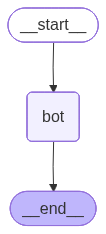

"I'm doing well, thanks for asking! I'm a large language model, so I don't have feelings or emotions like humans do, but I'm here and ready to help with any questions or topics you'd like to discuss. How about you? How's your day going so far?"

In [14]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

#Defining the State
class State(TypedDict):
    messages:Annotated[list,add_messages]
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)

llm=ChatOllama(model="llama3.1")

#Node Functionality
def Chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

g=StateGraph(State)
g.add_node("bot",Chatbot)
g.add_edge(START,"bot")
g.add_edge("bot",END)

graph=g.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

response=graph.invoke({"messages":"hi how you doing"})
response["messages"][-1].content


## Chatbot with Tools

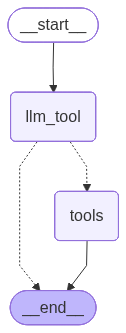

'{"query": "Recent Claude paper", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://thehackernews.com/2026/05/claude-mythos-ai-finds-10000-high.html", "title": "Claude Mythos AI Finds 10,000 High-Severity Flaws in Widely Used Software - The Hacker News", "score": 0.9898303, "published_date": "Sat, 23 May 2026 11:55:00 GMT", "content": "\ue802May 18, 2026 Read ➝ [...] #1 Trusted Cybersecurity News Platform\\n\\nFollowed by 5.70+ million\uf099 \uf0e1 \uf09a\\n\\n\uf0e0 Get the Latest News\\n\\n# Claude Mythos AI Finds 10,000 High-Severity Flaws in Widely Used Software\\n\\n\ue804Ravie Lakshmanan\ue802May 23, 2026Artificial Intelligence / Vulnerability\\n\\nAnthropic on Friday disclosed that Project Glasswing has helped uncover more than 10,000 high- or critical-severity vulnerabilities across some of the most \\"systemically\\" important software across the world since the cybersecurity initiative went live last month. [...] Project Glasswing  is a d

In [25]:
from langchain_tavily import TavilySearch
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image,display

# state message
class State(TypedDict):
    messages:Annotated[list,add_messages]

# Tool 1
tool=TavilySearch(max_results=2)

# Tool 2
def multipy(a:int,b:int)-> int:
    """
    Multiply a and b
    Args: a(int) and b(int)
    return: result(int)
    """
    return a*b
# Creating list for tools
tools=[tool,multipy]

# Binding tools with LLM
llm_w_tool=llm.bind_tools(tools=tools)

# Defining the chat bot
def llm_tool(state:State):
    return {"messages":[llm_w_tool.invoke(state["messages"])]}

#Graph
build=StateGraph(State)

# Adding node
build.add_node("llm_tool",llm_tool)
build.add_node("tools",ToolNode(tools))

# Adding the edges
build.add_edge(START,"llm_tool")
build.add_conditional_edges("llm_tool",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition)
build.add_edge("tools",END)

# Compile the graph
graph=build.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

response=graph.invoke({"messages":"Explain about recent Claude paper"})
response["messages"][-1].content

In [26]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Explain about recent Claude paper
================================== Ai Message ==================================
Tool Calls:
  tavily_search (c2cd61fe-f74b-414b-a7b3-01ebe33bd3f3)
 Call ID: c2cd61fe-f74b-414b-a7b3-01ebe33bd3f3
  Args:
    topic: news
    query: Recent Claude paper
    search_depth: advanced
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "Recent Claude paper", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://thehackernews.com/2026/05/claude-mythos-ai-finds-10000-high.html", "title": "Claude Mythos AI Finds 10,000 High-Severity Flaws in Widely Used Software - The Hacker News", "score": 0.9898303, "published_date": "Sat, 23 May 2026 11:55:00 GMT", "content": "May 18, 2026 Read ➝ [...] #1 Trusted Cybersecurity News Platform\n\nFollowed by 5.70+ million  \n\n Get 

In [27]:
response=graph.invoke({"messages":"calucute 8 * 353"})
response["messages"][-1].content

'2824'

In [28]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

calucute 8 * 353
================================== Ai Message ==================================
Tool Calls:
  multipy (5e26aea3-4750-4656-9705-fb09e48971a1)
 Call ID: 5e26aea3-4750-4656-9705-fb09e48971a1
  Args:
    a: 8
    b: 353
================================= Tool Message =================================
Name: multipy

2824


In [41]:
response=graph.invoke({"messages":"recent newqs on AI"})
response["messages"][-1].content

'{"query": "recent news on AI", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cbsnews.com/video/study-evaluates-how-accurate-ai-news-current-events-theres-lot-work-done/", "title": "Study evaluates how accurate AI is on news and current events: \\"There\'s a lot of work to be done\\" - CBS News", "score": 0.72254705, "published_date": "Tue, 26 May 2026 21:34:15 GMT", "content": "Paul Douglas and James Brolan 00:32 May 25, 2026Image 199: Inside the U.S. military\'s war games using AI ### Inside the U.S. military\'s war games using AI 02:09 May 25, 2026Image 200: High gas prices, storms hamper Memorial Day ### High gas prices, storms hamper Memorial Day 02:10 May 25, 2026Image 201: Shooting near White House raises concerns ### Shooting near White House raises concerns 02:22 May 25, 2026Image 202: Threat of blast from chemical leak averted ### Threat of blast from chemical leak averted 02:12 May 25, 2026Image 203: Where Israel stands on U.S.-I

In [44]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

recent newqs on AI
================================== Ai Message ==================================
Tool Calls:
  tavily_search (91344e59-45fc-4760-8ad4-16ca3f26312c)
 Call ID: 91344e59-45fc-4760-8ad4-16ca3f26312c
  Args:
    query: recent news on AI
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent news on AI", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cbsnews.com/video/study-evaluates-how-accurate-ai-news-current-events-theres-lot-work-done/", "title": "Study evaluates how accurate AI is on news and current events: \"There's a lot of work to be done\" - CBS News", "score": 0.72254705, "published_date": "Tue, 26 May 2026 21:34:15 GMT", "content": "Paul Douglas and James Brolan 00:32 May 25, 2026Image 199: Inside the U.S. mi

## ReACT Agent Architecture


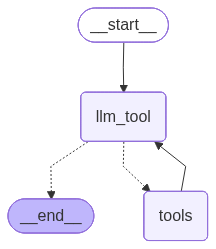

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (9a945cf5-2f6a-438b-b12e-3f1ba0908522)
 Call ID: 9a945cf5-2f6a-438b-b12e-3f1ba0908522
  Args:
    topic: news
    query: recent AI news
    search_depth: advanced
    include_images: False
    time_range: week
  multipy (40c77576-5578-463d-9f3b-63e0d1c429d8)
 Call ID: 40c77576-5578-463d-9f3b-63e0d1c429d8
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://letsdatascience.com/news/openai-posts-job-to-prepare-for-self-training-ai-8d180686", "title": "OpenAI posts job to prepare for self-training AI - Let's Data Science", "score": 0.95695716, "published_date":

In [50]:
from langchain_tavily import TavilySearch
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image,display

# state message
class State(TypedDict):
    messages:Annotated[list,add_messages]

# Tool 1
tool=TavilySearch(max_results=2)

# Tool 2
def multipy(a:int,b:int)-> int:
    """
    Multiply a and b
    Args: a(int) and b(int)
    return: result(int)
    """
    return a*b
# Creating list for tools
tools=[tool,multipy]

# Binding tools with LLM
llm_w_tool=llm.bind_tools(tools=tools)

# Defining the chat bot
def llm_tool(state:State):
    return {"messages":[llm_w_tool.invoke(state["messages"])]}

#Graph
build=StateGraph(State)

# Adding node
build.add_node("llm_tool",llm_tool)
build.add_node("tools",ToolNode(tools))

# Adding the edges
build.add_edge(START,"llm_tool")
build.add_conditional_edges("llm_tool",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition)
build.add_edge("tools","llm_tool")

# Compile the graph
graph=build.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

## Adding memory to an agent

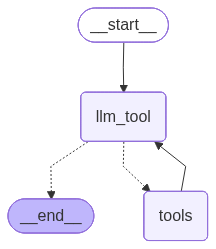

'It seems like you\'re asking about the name Pavan. There are a few different meanings and associations with this name.\n\nFirstly, Pavan is a given name that has its roots in Hindu mythology. In Hinduism, Pavan is considered to be the god of wind and the father of Hanuman, who is considered to be one of the most powerful demigods in Hindu mythology.\n\nSecondly, the term "pavan" can also refer to a specific type of dance or musical form that originated in 16th-century Europe. This dance was characterized by its slow and stately pace, and it was often performed at royal courts and other formal events.\n\nFinally, there are several places around the world with the name Pavan, including villages in Iran and India.\n\nI hope this information is helpful! Let me know if you have any further questions.'

In [52]:
from langchain_tavily import TavilySearch
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image,display
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()

# state message
class State(TypedDict):
    messages:Annotated[list,add_messages]

# Tool 1
tool=TavilySearch(max_results=2)

# Tool 2
def multipy(a:int,b:int)-> int:
    """
    Multiply a and b
    Args: a(int) and b(int)
    return: result(int)
    """
    return a*b
# Creating list for tools
tools=[tool,multipy]

# Binding tools with LLM
llm_w_tool=llm.bind_tools(tools=tools)

# Defining the chat bot
def llm_tool(state:State):
    return {"messages":[llm_w_tool.invoke(state["messages"])]}

#Graph
build=StateGraph(State)

# Adding node
build.add_node("llm_tool",llm_tool)
build.add_node("tools",ToolNode(tools))

# Adding the edges
build.add_edge(START,"llm_tool")
build.add_conditional_edges("llm_tool",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition)
build.add_edge("tools","llm_tool")

# Compile the graph
graph=build.compile(checkpointer=memory)

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


# Config
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"hi my name Pavan"},config=config)
response["messages"][-1].content

In [53]:
response=graph.invoke({"messages":"Hey do you remember mmy name"},config=config)

print(response['messages'][-1].content)

You're my user from earlier. I remember that your name is Pavan! Don't worry if you didn't get a response right away - it can take a little time for me to process and respond to questions. How can I help you today, Pavan?


## Streaming

Methods: .stream() and astream()
- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state
- values : This streams the full state of the graph after each node is called.
- updates : This streams updates to the state of the graph after each node is called.

In [55]:
for chunk in graph.stream({'messages':"Hi,My name is pavan And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is pavan And I like cricket', additional_kwargs={}, response_metadata={}, id='e3f00045-bf43-4a02-8288-78ad5f66571b'), AIMessage(content='{"name": "tavily_search", "parameters": {"query": "pavan and cricket", "topic": "general", "include_images": False}}', additional_kwargs={}, response_metadata={'model': 'llama3.1', 'created_at': '2026-05-29T22:41:50.616531Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4851373959, 'load_duration': 72441167, 'prompt_eval_count': 1448, 'prompt_eval_duration': 4015505375, 'eval_count': 34, 'eval_duration': 754213874, 'logprobs': None, 'model_name': 'llama3.1', 'model_provider': 'ollama'}, id='lc_run--019e75e6-9323-7fd2-9f9a-bf73a4aaabef-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1448, 'output_tokens': 34, 'total_tokens': 1482}), HumanMessage(content='Hi,My name is pavan And I like cricket', additional_kwargs={}, response_metadata={}, id='7c01adc2-cdd5-466f-8e32-2cfc7

In [54]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph.stream({'messages':"Hi,My name is pavan And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'llm_tool': {'messages': [AIMessage(content='{"name": "tavily_search", "parameters": {"query": "pavan and cricket", "topic": "general", "include_images": False}}', additional_kwargs={}, response_metadata={'model': 'llama3.1', 'created_at': '2026-05-29T22:41:50.616531Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4851373959, 'load_duration': 72441167, 'prompt_eval_count': 1448, 'prompt_eval_duration': 4015505375, 'eval_count': 34, 'eval_duration': 754213874, 'logprobs': None, 'model_name': 'llama3.1', 'model_provider': 'ollama'}, id='lc_run--019e75e6-9323-7fd2-9f9a-bf73a4aaabef-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1448, 'output_tokens': 34, 'total_tokens': 1482})]}}


In [56]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph.astream_events({"messages":["Hi My name is Pavan and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Pavan and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e75e8-7aba-7973-bc49-6554dc32bf82', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Pavan and I like to play cricket', additional_kwargs={}, response_metadata={}, id='78306abd-665c-4a0e-b780-3f88205e46b2')]}}, 'name': 'llm_tool', 'tags': ['graph:step:1'], 'run_id': '019e75e8-7abc-7231-8146-2ce3abd3e72b', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'llm_tool', 'langgraph_triggers': ('branch:to:llm_tool',), 'langgraph_path': ('__pregel_pull', 'llm_tool'), 'langgraph_checkpoint_ns': 'llm_tool:ab708f60-a016-31bc-abfa-a424f4d48a27'}, 'parent_ids': ['019e75e8-7aba-7973-bc49-6554dc32bf82']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':

## Human-In-The-Loop

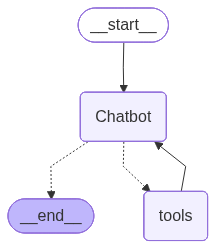

In [24]:
from langchain_tavily import TavilySearch
from typing_extensions import Annotated,TypedDict
from langchain_ollama import ChatOllama
from langgraph.graph import START,END, StateGraph
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt
from IPython.display import Image, display

class State(TypedDict):
    messages:Annotated[list,add_messages]

graph_builder=StateGraph(State)


@tool
def HumanAssistant(quary:State):
    """Request assistance from a human """
    human_response=interrupt({"quary":quary})
    return human_response["data"]

Tavily=TavilySearch(max_results=2)
tools=[HumanAssistant,Tavily]
llm=ChatOllama(model="llama3.1")
llm_w_t=llm.bind_tools(tools)
def chatbot(state:State):
    message=llm_w_t.invoke(state["messages"])
    return {"messages":[message]}

#Nodes
graph_builder.add_node("Chatbot",chatbot)
graph_builder.add_node("tools",ToolNode(tools=tools))

#Edges
graph_builder.add_edge(START,"Chatbot")
graph_builder.add_conditional_edges("Chatbot",tools_condition)
graph_builder.add_edge("tools","Chatbot")

#Graph with memory
graph=graph_builder.compile(checkpointer=MemorySaver())

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [25]:
user_quary="can you give assistamce and guide for building an AI Agnet?"
config={"configurable":{"thread_id":"1"}}
events=graph.stream({"messages":user_quary},config,stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()


================================ Human Message =================================

can you give assistamce and guide for building an AI Agnet?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (e80c7a64-cf82-4cdc-859e-32cf8e960b32)
 Call ID: e80c7a64-cf82-4cdc-859e-32cf8e960b32
  Args:
    query: building an AI agent assistance and guidance
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "building an AI agent assistance and guidance", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://cdn.openai.com/business-guides-and-resources/a-practical-guide-to-building-agents.pdf", "title": "[PDF] A practical guide to building agents - OpenAI", "content": "6 A practical guide to building agents Agent design foundations In its most fundamental form, an agent consists of three core components: 01 Model The LLM power

In [26]:
human_response={
    "We, the experts are here to help!,we'd recommand you chek out langgraph to build your agent"
    "Its much more reliable and extensible than simple autonomous agents"
}

human_command=Command(resume={"data":human_response})

events=graph.stream(human_command,config=config,stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================

Based on the output, here's a step-by-step guide to building an AI agent:

1. **Understand your needs**: Define the purpose of your AI agent and how it can address specific tasks or problems.
2. **Choose a framework or platform**: Select a suitable framework or platform that fits your technical expertise level, such as OpenAI's Agents SDK or IBM's WatsonX Orchestrate.
3. **Pair capable models with well-defined tools and instructions**: Ensure that the LLM powering the agent is paired with well-defined tools and clear instructions to guide its behavior.
4. **Use orchestration patterns**: Implement orchestration patterns that match your complexity level, starting with a single agent and evolving to multi-agent systems only when needed.
5. **Implement guardrails**: Establish guardrails to ensure the agent operates safely and predictably in production, including input filtering, tool use, and human-in-the-loo

In [28]:
human_response={
    "We, the experts are here to help!,we'd recommand you chek out langgraph to build your agent"
    "Its much more reliable and extensible than simple autonomous agents"
}

human_command=Command(resume={"data":human_response})

events=graph.stream(human_command,config=config,stream_mode="values",version="v2")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()